## Complete Pipeline: Plant Innoculation Robot

description

### Imports and libraries

In [49]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [50]:
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time

### Modules

In [51]:
from predictions import load_unet_model, predict_masks
from segmentation import segment_individual_plants_pipeline, create_skeleton_overlay
from main_root import extract_primary_root, process_multiple_plants
from pid_controller import (
    prepare_plate_texture, 
    inoculate_root_tips, 
    print_inoculation_summary
)
from sim_class import Simulation
from task10_pid_controller import PIDController

pybullet build time: Jan 29 2025 23:16:28


### Cropping Utilities

In [52]:
def to_grayscale(image):
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image


def segment_petri_dish(image):
    gray_image = to_grayscale(image)
    blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    return binary


def find_petri_dish_contour(binary_image):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest_contour = max(contours, key=cv2.contourArea)
    image_area = binary_image.shape[0] * binary_image.shape[1]
    contour_area = cv2.contourArea(largest_contour)
    if contour_area < 0.1 * image_area:
        return None
    x, y, w, h = cv2.boundingRect(largest_contour)
    aspect_ratio = float(w) / h if h != 0 else 0
    if 0.6 <= aspect_ratio <= 1.4:
        return largest_contour
    return None


def crop_to_contour(image, contour, padding=10):
    x, y, w, h = cv2.boundingRect(contour)
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(image.shape[1] - x, w + 2*padding)
    h = min(image.shape[0] - y, h + 2*padding)
    size = max(w, h)
    center_x = x + w // 2
    center_y = y + h // 2
    new_x = center_x - size // 2
    new_y = center_y - size // 2
    new_x = max(0, min(new_x, image.shape[1] - size))
    new_y = max(0, min(new_y, image.shape[0] - size))
    size = min(size, image.shape[1] - new_x, image.shape[0] - new_y)
    cropped_image = image[new_y:new_y+size, new_x:new_x+size]
    return cropped_image

### Parameters

In [53]:
MODEL_PATH = "AnaMariaFarazica_242845_unet_model_no_data_aug.h5"
INPUT_FOLDER = "Kaggle"
PATCH_SIZE = 256
THRESHOLD = 0.5
N_PLANTS = 5
GAP_CLOSING_RADIUS = 8

COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

# PID parameters
PID_KP = 5.0
PID_KI = 0.1
PID_KD = 1.2

### Random image from Input Dataset

In [54]:
image_files = sorted(Path(INPUT_FOLDER).glob("*.png"))
print(f"Found {len(image_files)} images in '{INPUT_FOLDER}'")

if len(image_files) == 0:
    raise FileNotFoundError(f"No PNG images found in '{INPUT_FOLDER}'")

random_image_path = random.choice(image_files)
image_name = random_image_path.stem
print(f"Selected: {random_image_path.name}\n")

Found 19 images in 'Kaggle'
Selected: test_image_18.png



### Semantic Segmentation using U-Net Model

In [55]:
print("Loading U-Net model...")
model = load_unet_model(MODEL_PATH)
print("✓ Model loaded successfully\n")

Loading U-Net model...
✓ Model loaded successfully



In [56]:
print("Running segmentation pipeline...")
try:
    results = predict_masks(
        image_path=random_image_path,
        model=model,
        patch_size=PATCH_SIZE,
        threshold=THRESHOLD
    )
    print("✓ Segmentation complete\n")
except Exception as e:
    print(f"✗ Error: {e}")
    raise

# Extract results
original_image = results['original']
root_mask = results['root_mask']
shoot_mask = results['shoot_mask']
seed_mask = results['seed_mask']
crop_coords = results['crop_coords']

print(f"Image shape: {original_image.shape}")
print(f"Crop coordinates (x, y, w, h): {crop_coords}")
print(f"Root pixels detected: {np.sum(root_mask > 0)}")
print(f"Shoot pixels detected: {np.sum(shoot_mask > 0)}")
print(f"Seed pixels detected: {np.sum(seed_mask > 0)}\n")


Running segmentation pipeline...
✓ Segmentation complete

Image shape: (3006, 4202)
Crop coordinates (x, y, w, h): (756, 51, 2782, 2782)
Root pixels detected: 7769
Shoot pixels detected: 5283
Seed pixels detected: 135



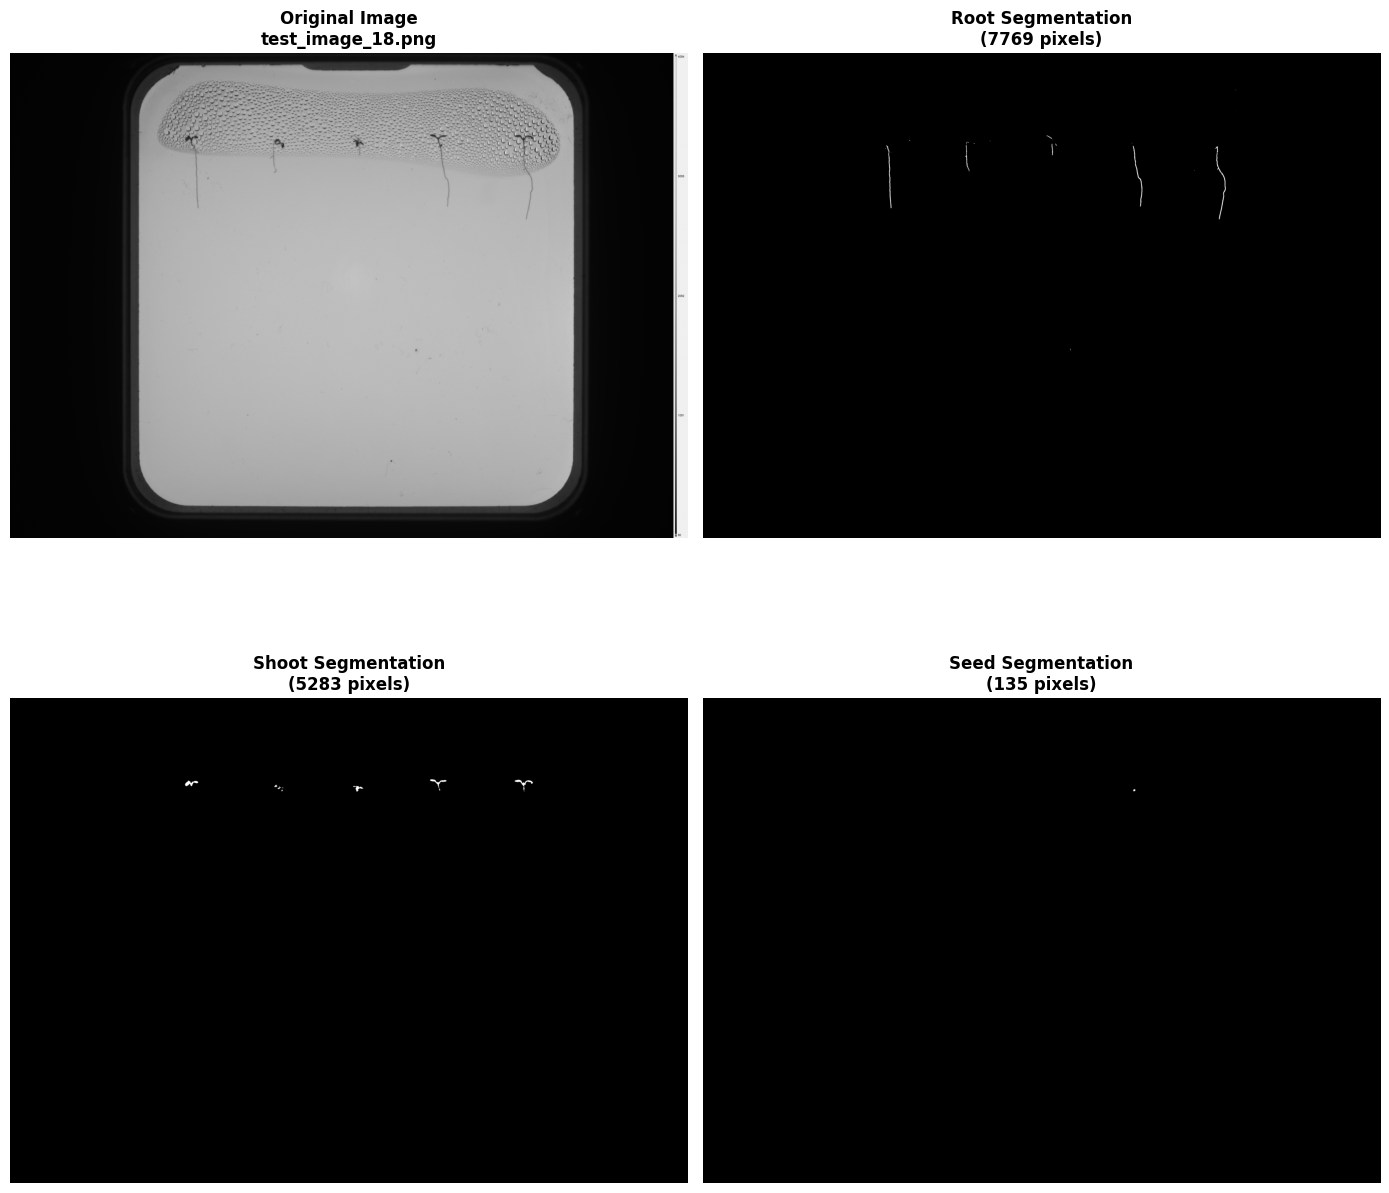

In [57]:
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Original image
axes[0, 0].imshow(original_image, cmap='gray')
axes[0, 0].set_title(f'Original Image\n{random_image_path.name}', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Root mask
axes[0, 1].imshow(root_mask, cmap='gray')
axes[0, 1].set_title(f'Root Segmentation\n({np.sum(root_mask > 0)} pixels)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Shoot mask
axes[1, 0].imshow(shoot_mask, cmap='gray')
axes[1, 0].set_title(f'Shoot Segmentation\n({np.sum(shoot_mask > 0)} pixels)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Seed mask
axes[1, 1].imshow(seed_mask, cmap='gray')
axes[1, 1].set_title(f'Seed Segmentation\n({np.sum(seed_mask > 0)} pixels)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

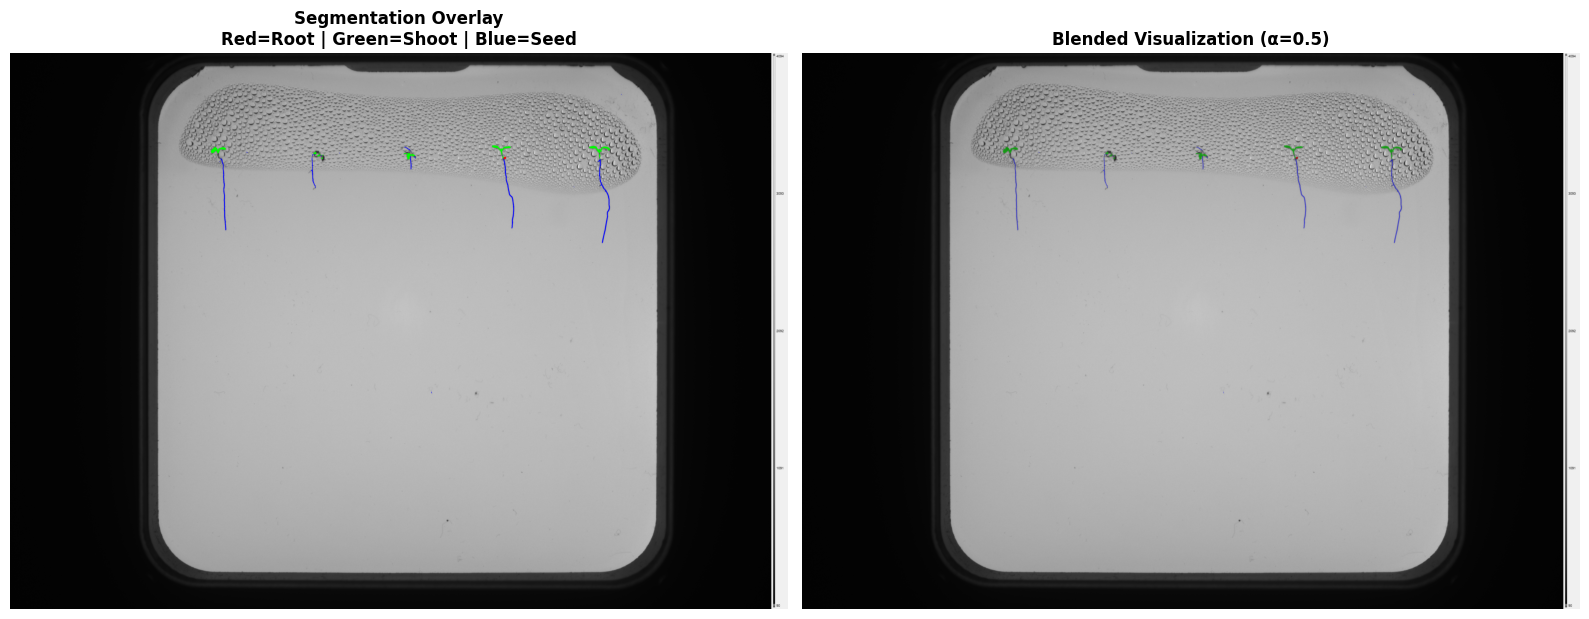

In [58]:
# OVERLAY VISUALIZATION
overlay = cv2.cvtColor(original_image, cv2.COLOR_GRAY2RGB)

overlay[root_mask > 0] = [255, 0, 0]      # Red for roots
overlay[shoot_mask > 0] = [0, 255, 0]     # Green for shoots
overlay[seed_mask > 0] = [0, 0, 255]      # Blue for seeds

alpha = 0.5
blended = cv2.addWeighted(
    cv2.cvtColor(original_image, cv2.COLOR_GRAY2RGB),
    1 - alpha,
    overlay,
    alpha,
    0
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[0].set_title('Segmentation Overlay\nRed=Root | Green=Shoot | Blue=Seed', 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Blended Visualization (α={alpha})', 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Instance Segmentation

In [59]:
print("="*70)
print("Cropping to Petri Dish")
print("="*70)

binary_full = segment_petri_dish(original_image)
contour = find_petri_dish_contour(binary_full)

if contour is None:
    raise ValueError("No petri dish detected in image")

# Crop all images/masks to petri dish
petri_dish_crop = crop_to_contour(original_image, contour)
root_mask_crop = crop_to_contour(root_mask, contour)
seed_mask_crop = crop_to_contour(seed_mask, contour)
shoot_mask_crop = crop_to_contour(shoot_mask, contour)

print(f"✓ Cropped to petri dish")
print(f"Original size: {original_image.shape}")
print(f"Cropped size: {petri_dish_crop.shape}\n")

Cropping to Petri Dish
✓ Cropped to petri dish
Original size: (3006, 4202)
Cropped size: (2762, 2762)



In [60]:
print("Instance Segmentation (Watershed)")

try:
    individual_plants = segment_individual_plants_pipeline(
        root_mask=root_mask_crop,
        seed_mask=seed_mask_crop,
        shoot_mask=shoot_mask_crop,
        n_plants=N_PLANTS
    )
    print(f"✓ Instance segmentation complete - {len(individual_plants)} plants separated\n")
except Exception as e:
    print(f"✗ Error: {e}")
    raise

# Print statistics for each plant
for i, plant_mask in enumerate(individual_plants):
    pixel_count = np.sum(plant_mask > 0)
    print(f"  Plant {i+1}: {pixel_count:,} pixels")

print()

Instance Segmentation (Watershed)
✓ Instance segmentation complete - 5 plants separated

  Plant 1: 2,249 pixels
  Plant 2: 839 pixels
  Plant 3: 562 pixels
  Plant 4: 2,090 pixels
  Plant 5: 2,923 pixels



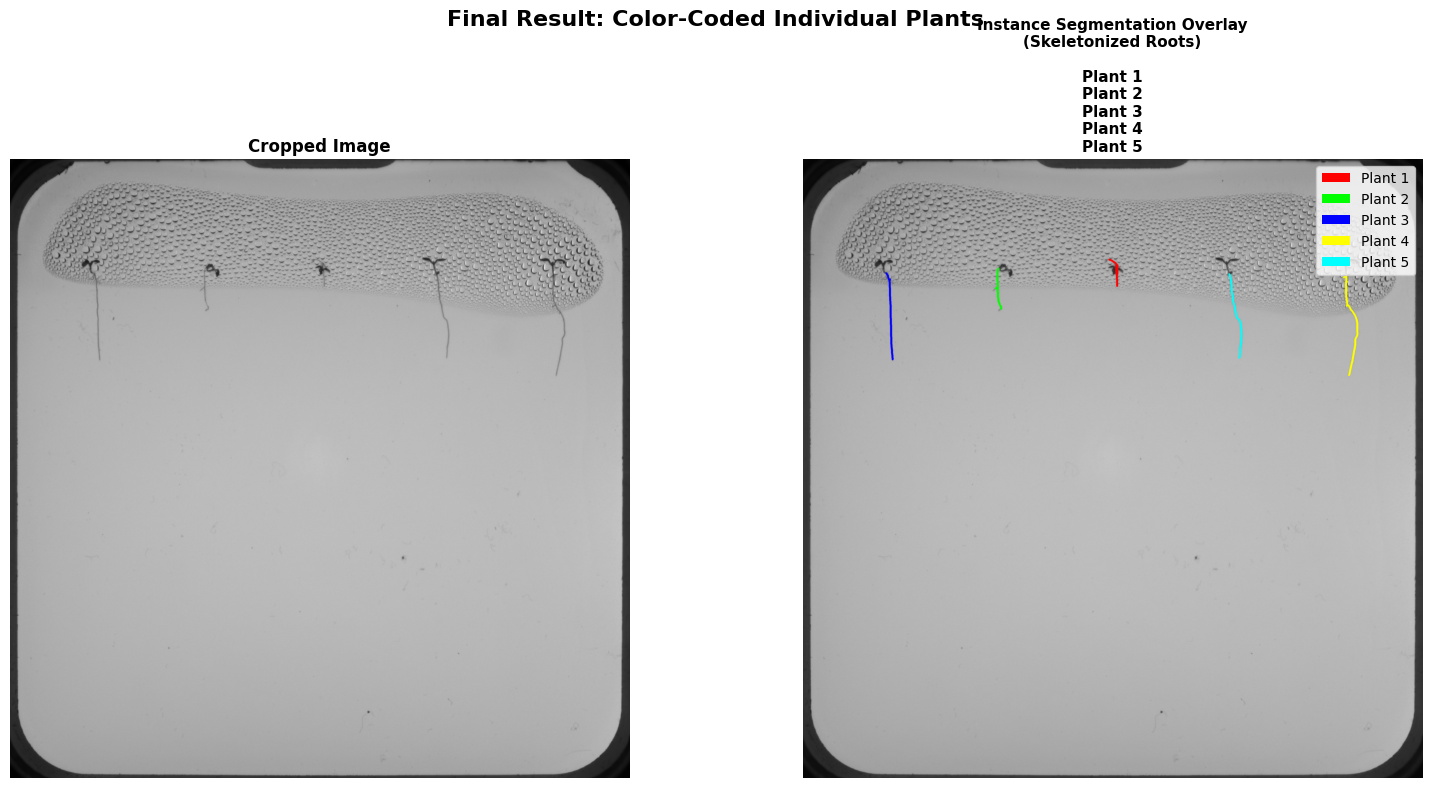

In [61]:
# VISUALIZATION 1: Color-Coded Overlay

overlay = create_skeleton_overlay(individual_plants, petri_dish_crop, colors=COLORS)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Cropped original
axes[0].imshow(petri_dish_crop, cmap='gray')
axes[0].set_title('Cropped Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Overlay with color legend
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
legend_text = '\n'.join([f'Plant {i+1}' for i in range(N_PLANTS)])
axes[1].set_title(f'Instance Segmentation Overlay\n(Skeletonized Roots)\n\n{legend_text}', 
                  fontsize=11, fontweight='bold')
axes[1].axis('off')

# Add color patches as legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=np.array(COLORS[i])/255, label=f'Plant {i+1}') 
                   for i in range(N_PLANTS)]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.suptitle('Final Result: Color-Coded Individual Plants', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


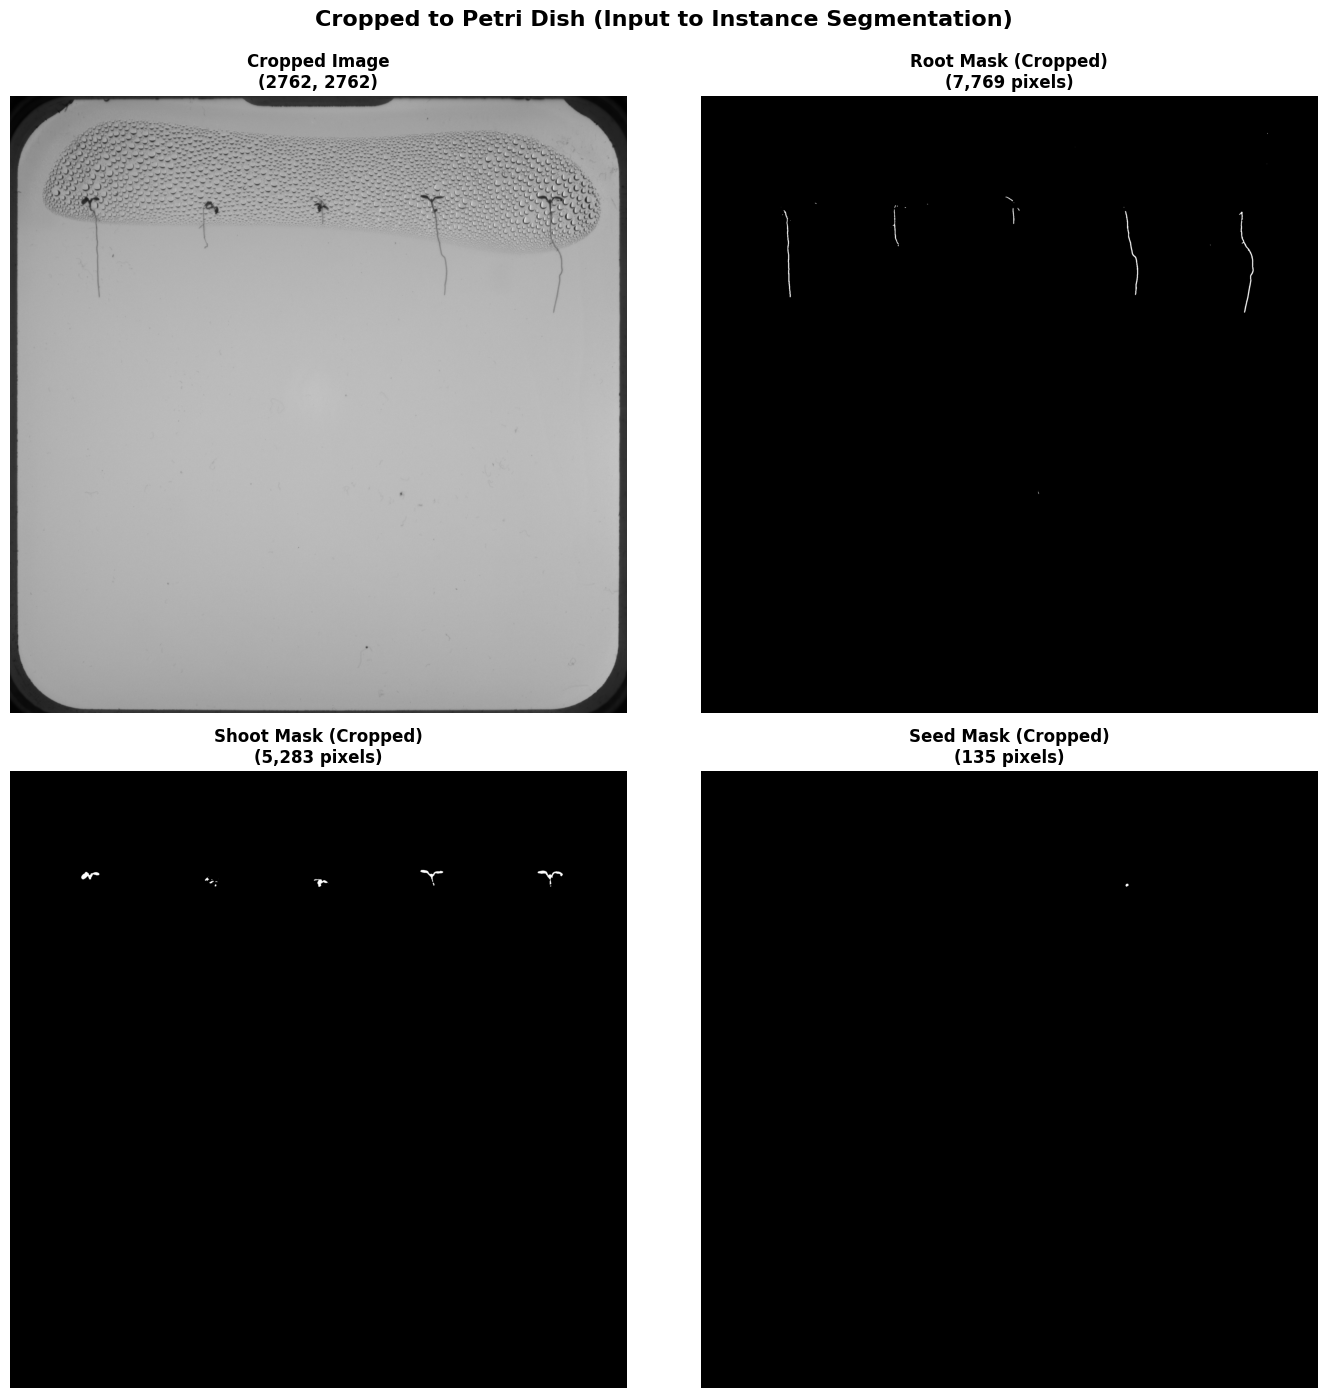

In [62]:
# VISUALIZATION 2: Cropped Masks for Instance Segmentation

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

axes[0, 0].imshow(petri_dish_crop, cmap='gray')
axes[0, 0].set_title(f'Cropped Image\n{petri_dish_crop.shape}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(root_mask_crop, cmap='gray')
axes[0, 1].set_title(f'Root Mask (Cropped)\n({np.sum(root_mask_crop > 0):,} pixels)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(shoot_mask_crop, cmap='gray')
axes[1, 0].set_title(f'Shoot Mask (Cropped)\n({np.sum(shoot_mask_crop > 0):,} pixels)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(seed_mask_crop, cmap='gray')
axes[1, 1].set_title(f'Seed Mask (Cropped)\n({np.sum(seed_mask_crop > 0):,} pixels)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Cropped to Petri Dish (Input to Instance Segmentation)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Primary Root Detection & Extraction of Root Tips

In [63]:
print("Primary Root Extraction & Root Tips")

primary_root_results = process_multiple_plants(
    plant_masks=individual_plants,
    gap_closing_radius=GAP_CLOSING_RADIUS
)

print(f"✓ Primary root extraction complete\n")

# Print results for each plant
measurements = {}
for i, result in enumerate(primary_root_results):
    if result is not None:
        root_tip = result['root_tip']
        length = result['length_pixels']
        attachment = result['attachment_point']
        
        measurements[str(i)] = {
            'length_pixels': length,
            'root_tip': root_tip,
            'attachment_point': attachment,
            'num_points': result['num_points']
        }
        
        print(f"  Plant {i+1}:")
        print(f"    Length: {length:.2f} pixels")
        print(f"    Root tip: {root_tip}")
        print(f"    Attachment: {attachment}")
    else:
        print(f"  Plant {i+1}: No root detected")
        measurements[str(i)] = {
            'length_pixels': 0.0,
            'root_tip': None,
            'attachment_point': None,
            'num_points': 0
        }

print()

Primary Root Extraction & Root Tips
✓ Primary root extraction complete

  Plant 1:
    Length: 397.60 pixels
    Root tip: (399, 900)
    Attachment: (371, 514)
  Plant 2:
    Length: 190.94 pixels
    Root tip: (883, 672)
    Attachment: (871, 491)
  Plant 3:
    Length: 140.94 pixels
    Root tip: (1400, 572)
    Attachment: (1365, 452)
  Plant 4:
    Length: 396.10 pixels
    Root tip: (1944, 888)
    Attachment: (1899, 518)
  Plant 5:
    Length: 484.45 pixels
    Root tip: (2433, 969)
    Attachment: (2421, 523)



In [64]:
# Create measurements dictionary matching original format
all_measurements = {
    image_name: measurements
}

# Save to JSON
output_json = 'primary_root_measurements.json'
with open(output_json, 'w') as f:
    json.dump(all_measurements, f, indent=2)

print(f"✓ Measurements saved to: {output_json}\n")

✓ Measurements saved to: primary_root_measurements.json



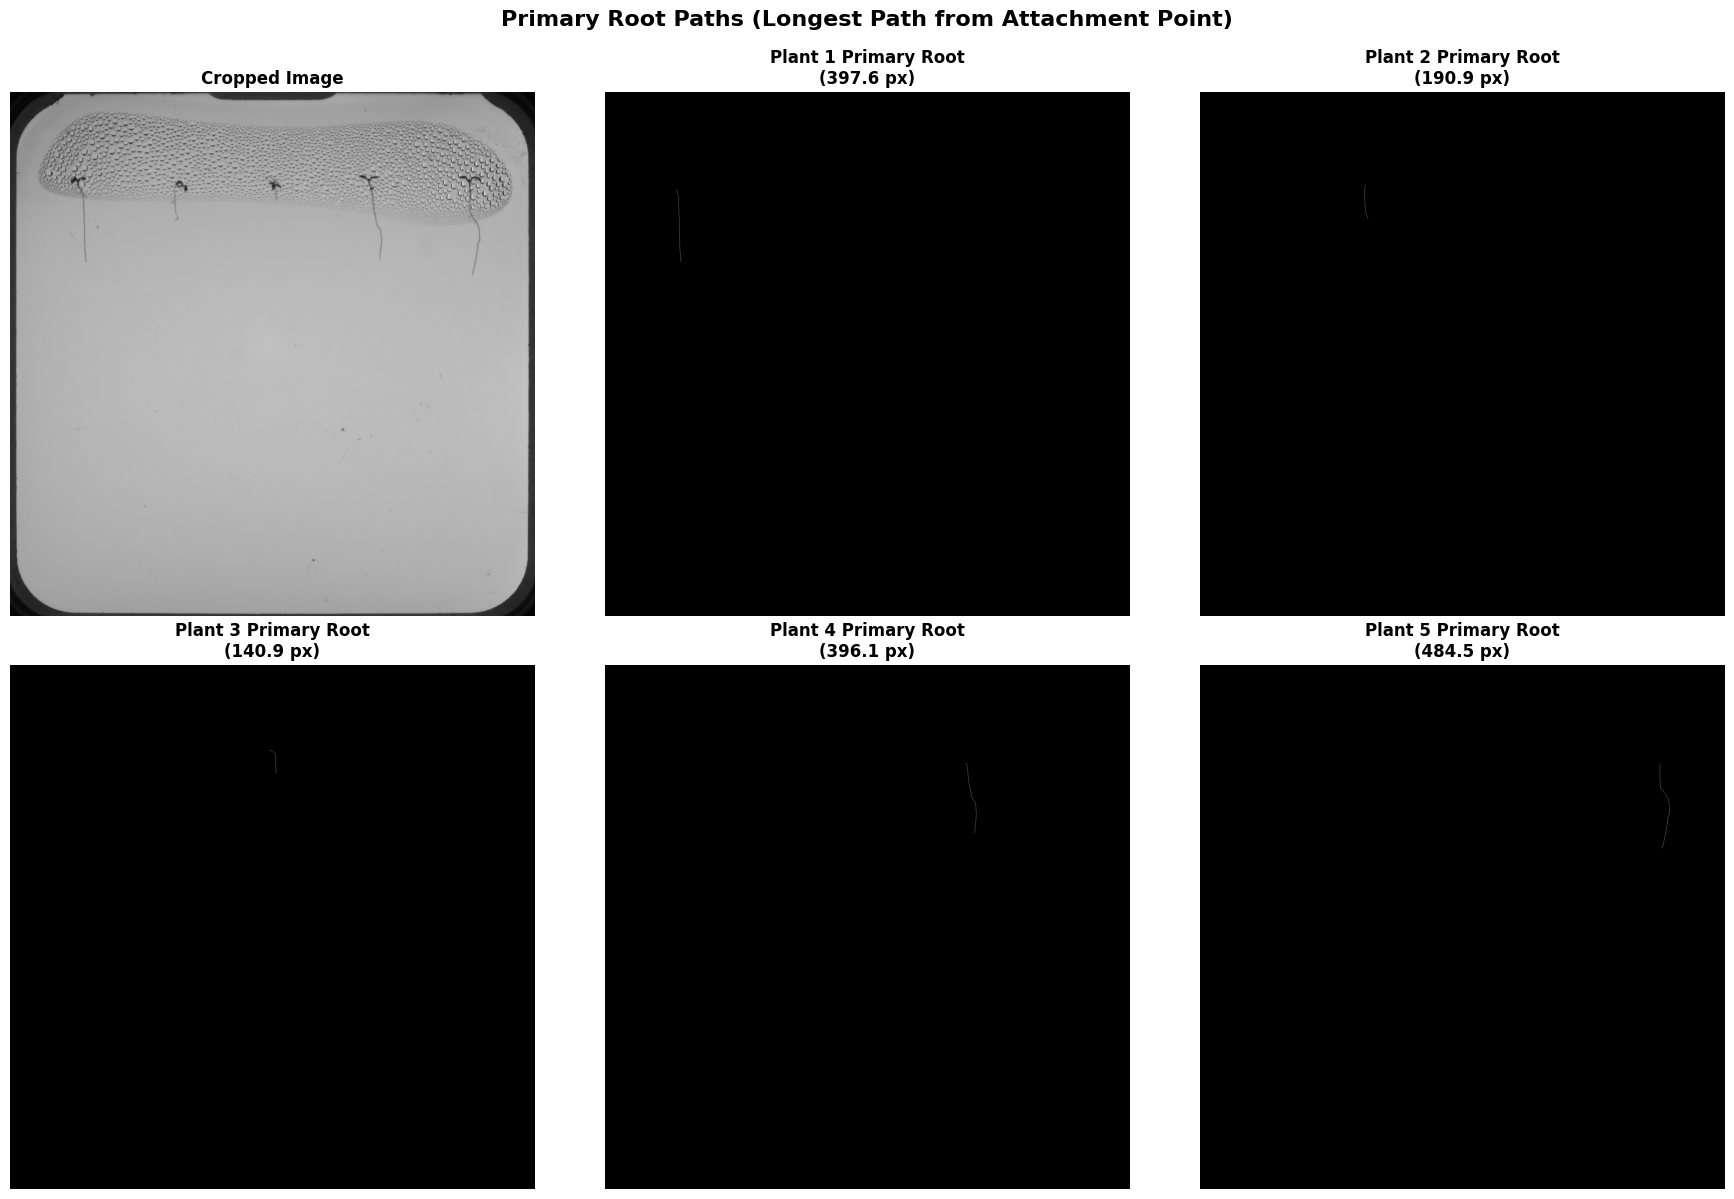

In [65]:
# VISUALIZATION 1: Primary Root Paths

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

axes[0].imshow(petri_dish_crop, cmap='gray')
axes[0].set_title('Cropped Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

for i in range(N_PLANTS):
    if primary_root_results[i] is not None:
        primary_mask = primary_root_results[i]['primary_root_mask']
        axes[i+1].imshow(primary_mask, cmap='gray')
        axes[i+1].set_title(f'Plant {i+1} Primary Root\n({primary_root_results[i]["length_pixels"]:.1f} px)', 
                           fontsize=12, fontweight='bold')
    else:
        axes[i+1].imshow(np.zeros_like(petri_dish_crop), cmap='gray')
        axes[i+1].set_title(f'Plant {i+1}\nNo root', fontsize=12, fontweight='bold')
    axes[i+1].axis('off')

plt.suptitle('Primary Root Paths (Longest Path from Attachment Point)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

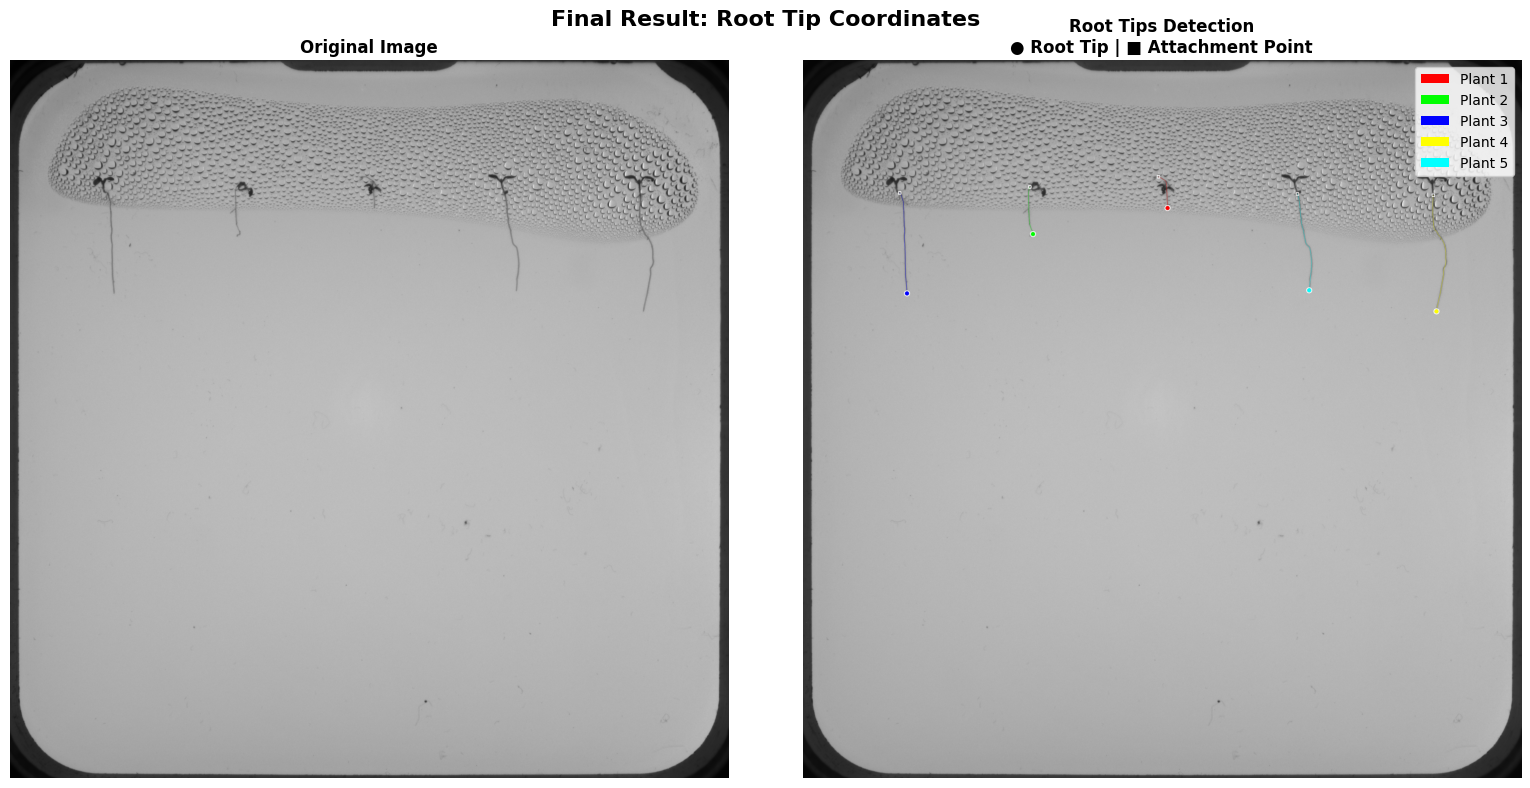

In [66]:
# VISUALIZATION 2: Root Tips Overlay

# Create overlay with root tips marked
overlay = cv2.cvtColor(petri_dish_crop, cv2.COLOR_GRAY2RGB)

for i, result in enumerate(primary_root_results):
    if result is not None:
        root_tip = result['root_tip']
        attachment = result['attachment_point']
        
        # Draw primary root path in color
        primary_mask = result['primary_root_mask']
        overlay[primary_mask > 0] = COLORS[i]
        
        # Mark root tip with circle
        cv2.circle(overlay, root_tip, 10, (255, 255, 255), 2)
        cv2.circle(overlay, root_tip, 8, COLORS[i], -1)
        
        # Mark attachment point with square
        cv2.rectangle(overlay, 
                     (attachment[0]-5, attachment[1]-5),
                     (attachment[0]+5, attachment[1]+5),
                     (255, 255, 255), 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(petri_dish_crop, cmap='gray')
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Root Tips Detection\n● Root Tip | ■ Attachment Point', 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=np.array(COLORS[i])/255, label=f'Plant {i+1}') 
                   for i in range(N_PLANTS)]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.suptitle('Final Result: Root Tip Coordinates', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### PID Controller Integration

In [67]:
print("Prepare Robot Simulation")

# Prepare texture
texture_output_path = f"{INPUT_FOLDER}/{image_name}_texture.png"
print("Preparing plate texture...")

try:
    orig_width, orig_height, dish_bbox = prepare_plate_texture(
        str(random_image_path), 
        texture_output_path
    )
    print(f"✓ Texture created: {orig_width}×{orig_height} image")
    
    if dish_bbox:
        x, y, w, h = dish_bbox
        print(f"✓ Dish detected at center: ({x + w/2:.0f}, {y + h/2:.0f})")
        print(f"  Dish radius: {(w + h)/4:.0f} pixels")
except Exception as e:
    print(f"✗ Error preparing texture: {e}")
    texture_output_path = None
    dish_bbox = None

print()

Prepare Robot Simulation
Preparing plate texture...
  ✓ Detected dish at (797, 71) with size 2700×2742
✓ Texture created: 4202×3006 image
✓ Dish detected at center: (2147, 1442)
  Dish radius: 1360 pixels



In [68]:
print("Robot Inoculation")

print("Initializing simulation...")
if texture_output_path and os.path.exists(texture_output_path):
    sim = Simulation(num_agents=1, render=True, plate_image_path=texture_output_path)
else:
    sim = Simulation(num_agents=1, render=True)

# Initialize PID controllers
pid_x = PIDController(Kp=PID_KP, Ki=PID_KI, Kd=PID_KD)
pid_y = PIDController(Kp=PID_KP, Ki=PID_KI, Kd=PID_KD)
pid_z = PIDController(Kp=PID_KP, Ki=PID_KI, Kd=PID_KD)

print("✓ Simulation initialized")
print("✓ PID controllers ready")
print()

Robot Inoculation
Initializing simulation...
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor = Mesa
Renderer = llvmpipe (LLVM 20.1.2, 256 bits)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Mesa
ven = Mesa
✓ Simulation initialized
✓ PID controllers ready



In [69]:
print("Starting inoculation sequence...")

inoculation_results = inoculate_root_tips(
    sim=sim,
    pid_controllers=(pid_x, pid_y, pid_z),
    root_tips_data=measurements,
    dish_bbox=dish_bbox,
    image_width=orig_width,
    image_height=orig_height
)

Starting inoculation sequence...

Processing 5 root tips...

--- Plant 0 ---
  Root tip (pixels): (399, 900)
  Target (robot): [0.0831, -0.0094, 0.0950]
  Moving to target...
    Final error: 0.479mm
    Min error reached: 0.479mm
  ✓ Reached target in 310 iterations (error: 0.000479m)
  ✓ Drop completed

--- Plant 1 ---
  Root tip (pixels): (883, 672)
  Target (robot): [0.0706, 0.0173, 0.0950]
  Moving to target...
    Final error: 0.497mm
    Min error reached: 0.497mm
  ✓ Reached target in 253 iterations (error: 0.000497m)
  ✓ Drop completed

--- Plant 2 ---
  Root tip (pixels): (1400, 572)
  Target (robot): [0.0650, 0.0458, 0.0950]
  Moving to target...
    Final error: 0.492mm
    Min error reached: 0.492mm
  ✓ Reached target in 253 iterations (error: 0.000492m)
  ✓ Drop completed

--- Plant 3 ---
  Root tip (pixels): (1944, 888)
  Target (robot): [0.0825, 0.0758, 0.0950]
  Moving to target...
    Final error: 0.496mm
    Min error reached: 0.496mm
  ✓ Reached target in 259 iterat

In [70]:
print_inoculation_summary(inoculation_results)

# Save results
all_measurements = {
    image_name: measurements
}

output_json = 'primary_root_measurements.json'
with open(output_json, 'w') as f:
    json.dump(all_measurements, f, indent=2)

results_output = 'inoculation_results.json'
with open(results_output, 'w') as f:
    json.dump({
        'image': image_name,
        'cv_results': measurements,
        'inoculation_results': inoculation_results
    }, f, indent=2)

print(f"\n✓ Results saved:")
print(f"  - {output_json}")
print(f"  - {results_output}")


INOCULATION SUMMARY
  Successful inoculations: 5/5
  Failed inoculations: 0/5

  Average iterations: 265.0
  Average error: 0.491mm
  Position adjustments: 0

✓ Results saved:
  - primary_root_measurements.json
  - inoculation_results.json


In [71]:
print("\nSimulation running. Press Ctrl+C to close.")
print("Waiting 5 seconds before closing...")
time.sleep(5)

print("\nClosing simulation...")
sim.close()
print("✓ Pipeline complete!")

print("\n" + "="*70)
print("END OF PIPELINE")
print("="*70)


Simulation running. Press Ctrl+C to close.
Waiting 5 seconds before closing...

Closing simulation...
numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
✓ Pipeline complete!

END OF PIPELINE
